#Dividir el dataset en conjunto de entrenamiento y conjunto de testing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data = pd.read_csv("/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/ads/Advertising.csv")

In [4]:
len(data)

200

In [5]:
a = np.random.randn(len(data))

In [6]:
a

array([-0.31279957,  0.21633677, -1.35146626, -0.91047529,  0.56651791,
        1.85545793, -0.22451021,  0.33790141, -1.54500719,  0.15647098,
       -0.14903609,  0.08952603, -0.23255164, -1.27336537, -0.92804579,
        1.70978591,  0.05627332, -0.09426596, -0.38433765, -0.94299115,
        1.60332014, -0.524201  ,  0.83947004, -0.11630872,  0.31034557,
        1.67498104, -0.65336158, -1.558768  ,  0.64150489,  0.55769118,
       -1.18169536,  0.76470802,  0.83687893, -0.80036069,  1.93080003,
       -1.29148893,  0.96310258, -0.26748448, -0.85677476, -0.11621191,
        0.35224707,  0.16097951, -1.83608655,  0.59371196, -0.31188715,
        0.06736984, -0.14946695, -1.94681006, -0.63809188, -1.19357553,
        0.37019433, -0.25936037, -1.11026671,  0.06342038, -0.86458687,
       -0.65988297, -1.80508888, -2.33398703,  0.45924042,  0.60422121,
       -0.35605379,  0.55557725,  0.20723552,  1.4235096 ,  0.95143186,
       -0.54145705, -2.79733393,  0.52398246,  1.60742545, -0.11

In [7]:
len(a)

200

(array([ 4.,  8., 10., 13., 36., 39., 37., 30., 10., 13.]),
 array([-2.79733393, -2.32452053, -1.85170714, -1.37889374, -0.90608035,
        -0.43326695,  0.03954644,  0.51235984,  0.98517323,  1.45798663,
         1.93080003]),
 <BarContainer object of 10 artists>)

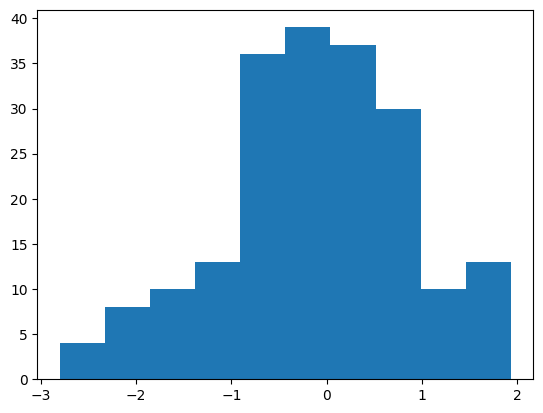

In [8]:
plt.hist(a)

In [9]:
check = (a < 0.8)

In [10]:
check

array([ True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True, False,  True, False,  True,  True, False,  True,
        True,  True,  True,  True,  True, False,  True, False,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False,  True,  True,  True, False,  True, False,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False,  True,  True,
        True, False,

In [11]:
data[check]

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
193,166.8,42.0,3.6,19.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [12]:
data[~ check]

,TV,Radio,Newspaper,Sales
5,8.7,48.9,75.0,7.2
15,195.4,47.7,52.9,22.4
20,218.4,27.7,53.4,18.0
22,13.2,15.9,49.6,5.6
25,262.9,3.5,19.5,12.0
32,97.2,1.5,30.0,9.6
34,95.7,1.4,7.4,9.5
36,266.9,43.8,5.0,25.4
63,102.7,29.6,8.4,14.0
64,131.1,42.8,28.9,18.0


In [13]:
training = data[check]
testing = data[~ check]

In [15]:
import statsmodels.formula.api as smf

In [16]:
lm_training = smf.ols(formula = "Sales ~ TV + Radio", data = training).fit()

In [17]:
lm_training.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     746.2
Date:                Fri, 03 Nov 2023   Prob (F-statistic):           2.18e-83
Time:                        16:33:03   Log-Likelihood:                -323.46
No. Observations:                 168   AIC:                             652.9
Df Residuals:                     165   BIC:                             662.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8852      0.318      9.081      0.000       2.258       3.512
TV             0.0458      0.002     30.414      0.000       0.043       0.049
Radio          0.1899      0.009     21.650      0.000       0.173       0.207
==============================================================================
Omnibus:                       55.445   Durbin-Watson:                   2.038
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.720
Skew:                          -1.356   Prob(JB):                     1.13e-33
Kurtosis:                       6.785   Cond. No.                         422.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##Ahora tenemos el modelo lineal:

`Sales = 2.8527	+ 0.0469 * TV + 0.1859 * Radio`

##Validación del modelo con el conjunto de "testing".

In [20]:
sales_pred = lm_training.predict(testing)

In [21]:
sales_pred

5      12.567861
15     20.883526
20     18.138648
22      6.508121
25     15.580176
32      7.617905
34      7.530277
36     23.414922
63     13.204895
64     17.010762
68     18.970126
70     17.806087
77     13.810579
80     11.450772
95     16.357726
96     12.592008
101    23.340846
112    13.849287
122    13.591233
123    15.087755
127     6.555172
134    11.902664
145     9.666135
154    15.485241
159    12.405425
163    17.354195
166    10.843344
169    17.907520
172     7.598437
184    18.543415
194    16.494856
195     5.335740
dtype: float64

In [22]:
testing

,TV,Radio,Newspaper,Sales
5,8.7,48.9,75.0,7.2
15,195.4,47.7,52.9,22.4
20,218.4,27.7,53.4,18.0
22,13.2,15.9,49.6,5.6
25,262.9,3.5,19.5,12.0
32,97.2,1.5,30.0,9.6
34,95.7,1.4,7.4,9.5
36,266.9,43.8,5.0,25.4
63,102.7,29.6,8.4,14.0
64,131.1,42.8,28.9,18.0


In [23]:
#SSD = Suma de los cuadrados de las diferencias (errores)
SSD = sum((testing["Sales"] - sales_pred) ** 2)
SSD

94.53371217692964

In [24]:
RSE = np.sqrt(SSD / (len(testing) - 2 - 1))

In [25]:
RSE

1.805486964371334

In [26]:
sales_mean = np.mean(testing["Sales"])
sales_mean

13.990625

In [27]:
error = RSE / sales_mean
error

0.12904977185589164